In [2]:
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Chargement des données
df = pd.read_csv("data/divorces_2000-2015_translated.csv")

# 2. Fonction de correction des dates (gestion du siècle)
def clean_date_century(x):
    if pd.isnull(x):
        return pd.NaT
    # Si l'année est dans le futur (ex: 2055), on retire 100 ans (-> 1955)
    if x.year > 2020:
        return x - pd.DateOffset(years=100)
    return x

# 3. Conversion propre des dates avec le format explicite
date_cols = ['DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage', 'Divorce_date']

for col in date_cols:
    # On force le format jour/mois/année (2 chiffres pour l'année)
    # errors='coerce' transforme les erreurs en NaT (Not a Time)
    df[col] = pd.to_datetime(df[col], format='%d/%m/%y', errors='coerce')
    # On applique la correction de siècle
    df[col] = df[col].apply(clean_date_century)

# 4. Création des nouvelles variables (Feature Engineering)
# Âge au moment du mariage (plus précis que la date de naissance brute)
df['Age_at_marriage_man'] = (df['Date_of_marriage'] - df['DOB_partner_man']).dt.days / 365.25
df['Age_at_marriage_woman'] = (df['Date_of_marriage'] - df['DOB_partner_woman']).dt.days / 365.25

# Écart d'âge (valeur absolue)
df['Age_diff'] = abs(df['Age_at_marriage_man'] - df['Age_at_marriage_woman'])

# Gestion des revenus (Remplacer les vides par la médiane pour éviter de perdre des données)
df['Monthly_income_partner_man_peso'] = df['Monthly_income_partner_man_peso'].fillna(df['Monthly_income_partner_man_peso'].median())
df['Monthly_income_partner_woman_peso'] = df['Monthly_income_partner_woman_peso'].fillna(df['Monthly_income_partner_woman_peso'].median())

# Revenu total du ménage et part de l'homme (indicateurs économiques)
df['Income_Total'] = df['Monthly_income_partner_man_peso'] + df['Monthly_income_partner_woman_peso']
df['Income_Share_Man'] = df['Monthly_income_partner_man_peso'] / df['Income_Total']
# Remplacer les divisions par zéro éventuelles
df['Income_Share_Man'] = df['Income_Share_Man'].fillna(0.5)

# Nombre d'enfants (Remplacer NaN par 0)
df['Num_Children'] = df['Num_Children'].fillna(0)

# 5. Filtrage des données aberrantes
# On garde les mariages où les âges sont réalistes (ex: > 15 ans et < 100 ans)
mask_valid = (df['Age_at_marriage_man'] > 15) & (df['Age_at_marriage_woman'] > 15) & (df['Age_at_marriage_man'] < 100)
df_clean = df[mask_valid].copy()

print(f"Nombre de lignes après nettoyage : {len(df_clean)}")
df_clean[['Age_at_marriage_man', 'Age_at_marriage_woman', 'Age_diff', 'Income_Total']].head()

Nombre de lignes après nettoyage : 4334


,Age_at_marriage_man,Age_at_marriage_woman,Age_diff,Income_Total
0,24.522930,17.464750,7.058179,3800.0
2,20.818617,28.744695,7.926078,10600.0
4,23.041752,20.087611,2.954141,23000.0
5,21.815195,18.600958,3.214237,10600.0
6,20.673511,19.780972,0.892539,10600.0


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. CHARGEMENT ET NETTOYAGE DES DATES ---
df = pd.read_csv("data/divorces_2000-2015_translated.csv")

# Fonction pour corriger les années (ex: 2060 -> 1960)
def clean_date_century(x):
    if pd.isnull(x): return pd.NaT
    if x.year > 2020: return x - pd.DateOffset(years=100)
    return x

date_cols = ['DOB_partner_man', 'DOB_partner_woman', 'Date_of_marriage']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%d/%m/%y', errors='coerce')
    df[col] = df[col].apply(clean_date_century)

# --- 2. CRÉATION DES VARIABLES (Feature Engineering) ---
# Âges
df['Age_at_marriage_man'] = (df['Date_of_marriage'] - df['DOB_partner_man']).dt.days / 365.25
df['Age_at_marriage_woman'] = (df['Date_of_marriage'] - df['DOB_partner_woman']).dt.days / 365.25
df['Age_diff'] = abs(df['Age_at_marriage_man'] - df['Age_at_marriage_woman'])

# Revenus (Remplacer NaN par médiane)
df['Monthly_income_partner_man_peso'] = df['Monthly_income_partner_man_peso'].fillna(df['Monthly_income_partner_man_peso'].median())
df['Monthly_income_partner_woman_peso'] = df['Monthly_income_partner_woman_peso'].fillna(df['Monthly_income_partner_woman_peso'].median())

# Indicateurs économiques
df['Income_Total'] = df['Monthly_income_partner_man_peso'] + df['Monthly_income_partner_woman_peso']

# --- 3. NETTOYAGE FINAL CRUCIAL (C'est ici que l'erreur est corrigée) ---

# A. Nettoyage de la CIBLE (y)
# On s'assure que la durée est bien un chiffre
df['Marriage_duration'] = pd.to_numeric(df['Marriage_duration'], errors='coerce')
# On supprime les lignes où la durée du mariage est inconnue
df = df.dropna(subset=['Marriage_duration'])

# B. Sélection des features
features = ['Age_at_marriage_man', 'Age_at_marriage_woman', 'Age_diff',
            'Income_Total', 'Num_Children',
            'Level_of_education_partner_man', 'Level_of_education_partner_woman']

df_model = df[features + ['Marriage_duration']].copy()

# C. Encodage One-Hot
df_model = pd.get_dummies(df_model, columns=['Level_of_education_partner_man', 'Level_of_education_partner_woman'], drop_first=True)

# D. Gestion des valeurs infinies et NaNs restants dans X
# Remplacer l'infini par NaN
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
# Remplacer tous les NaNs restants par 0
df_model.fillna(0, inplace=True)

# --- 4. MODÉLISATION ---
X = df_model.drop(columns=['Marriage_duration'])
y = df_model['Marriage_duration']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
# Attention : fit_transform peut renvoyer des NaN si une colonne a une variance de 0,
# mais c'est rare après notre nettoyage.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèles
models = {
    "Régression Linéaire": LinearRegression(),
    "KNN (k=20)": KNeighborsRegressor(n_neighbors=20),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
}

print("Résultats des modèles :")
for name, model in models.items():
    if name == "Random Forest":
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.3f}")

Résultats des modèles :
--- Régression Linéaire ---
RMSE: 8.30
R2: 0.252
--- KNN (k=20) ---
RMSE: 8.14
R2: 0.282
--- Random Forest ---
RMSE: 7.90
R2: 0.323


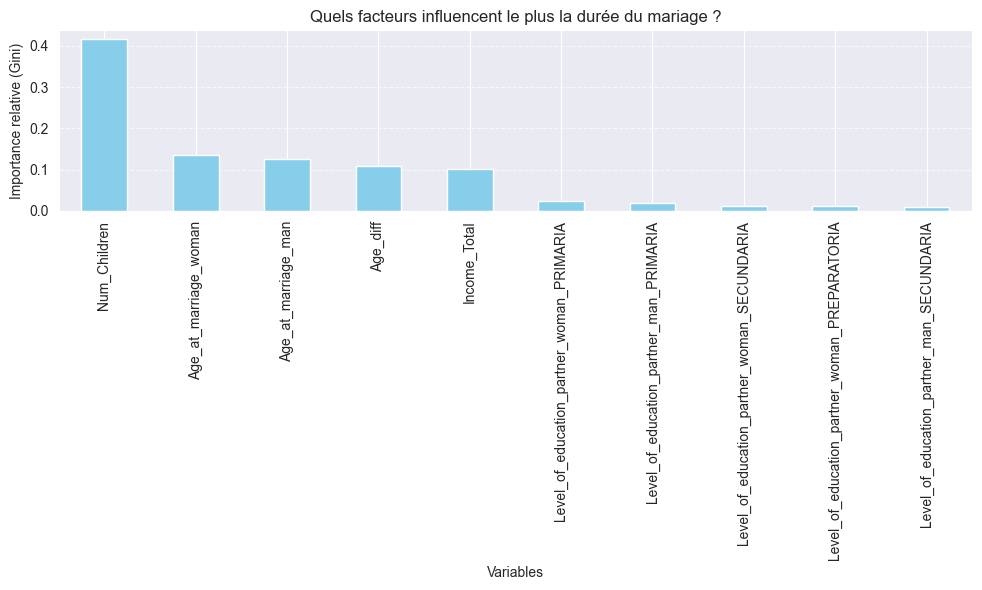

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# On récupère le modèle Random Forest entraîné précédemment
rf_model = models["Random Forest"]

# On récupère l'importance des features
importances = rf_model.feature_importances_
feature_names = X.columns

# Création d'un DataFrame pour l'affichage
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Affichage graphique
plt.figure(figsize=(10, 6))
forest_importances.head(10).plot(kind='bar', color='skyblue')
plt.title("Quels facteurs influencent le plus la durée du mariage ?")
plt.ylabel("Importance relative (Gini)")
plt.xlabel("Variables")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Rapport de Classification :
                  precision    recall  f1-score   support

  Court (<5 ans)       0.50      0.47      0.49       251
  Long (>15 ans)       0.58      0.53      0.55       300
Moyen (5-15 ans)       0.46      0.51      0.49       387

        accuracy                           0.51       938
       macro avg       0.51      0.51      0.51       938
    weighted avg       0.51      0.51      0.51       938



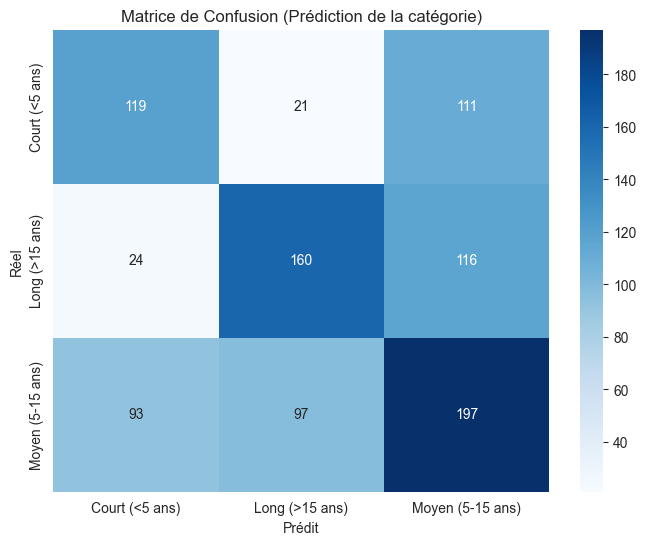

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Discrétisation de la cible (Création de classes)
# On définit : Court (< 5 ans), Moyen (5-15 ans), Long (> 15 ans)
def categorize_duration(years):
    if years < 5:
        return "Court (<5 ans)"
    elif years < 15:
        return "Moyen (5-15 ans)"
    else:
        return "Long (>15 ans)"

y_class = df_model['Marriage_duration'].apply(categorize_duration)

# 2. Split avec la nouvelle cible
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

# 3. Entraînement d'un Classifier (et non plus Regressor)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)

# 4. Évaluation
y_pred_c = clf.predict(X_test_c)

print("Rapport de Classification :")
print(classification_report(y_test_c, y_pred_c))

# 5. Matrice de confusion (pour voir où il se trompe)
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_c, y_pred_c), annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Matrice de Confusion (Prédiction de la catégorie)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()


--- RAPPORT CLASSIFICATION BINAIRE ---
                       precision    recall  f1-score   support

Court/Moyen (<10 ans)       0.71      0.78      0.74       465
      Long (>=10 ans)       0.76      0.69      0.73       473

             accuracy                           0.74       938
            macro avg       0.74      0.74      0.74       938
         weighted avg       0.74      0.74      0.74       938



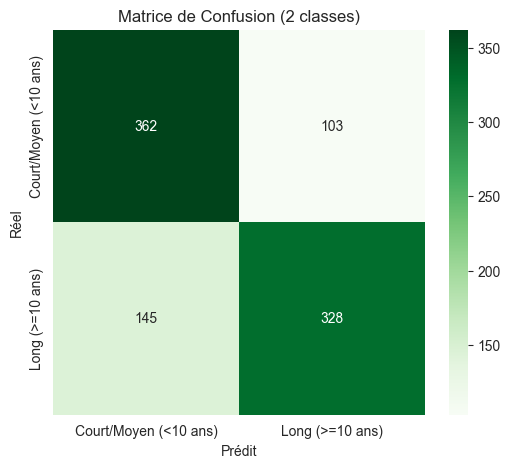

In [6]:
# --- Test de la Classification Binaire (Pour améliorer le score) ---
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. On simplifie le problème : Court (< 10 ans) vs Long (>= 10 ans)
# C'est plus facile pour l'IA de trancher
def categorize_binary(years):
    if years < 10:
        return "Court/Moyen (<10 ans)"
    else:
        return "Long (>=10 ans)"

# On applique la transformation
y_bin = df_model['Marriage_duration'].apply(categorize_binary)

# 2. Split des données
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# 3. Entraînement
clf_bin = RandomForestClassifier(n_estimators=100, random_state=42)
clf_bin.fit(X_train_b, y_train_b)

# 4. Résultats
y_pred_b = clf_bin.predict(X_test_b)

print("--- RAPPORT CLASSIFICATION BINAIRE ---")
print(classification_report(y_test_b, y_pred_b))

# 5. Matrice de confusion visuelle
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_b, y_pred_b), annot=True, fmt='d', cmap='Greens',
            xticklabels=clf_bin.classes_, yticklabels=clf_bin.classes_)
plt.title("Matrice de Confusion (2 classes)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

In [7]:
# --- Test du modèle "Honnête" (Sans la variable Num_Children) ---
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# 1. On part de X (qui contient toutes les variables déjà encodées)
# et on retire seulement le nombre d'enfants.
X_honest = X.drop(columns=['Num_Children'])

# On garde la cible binaire (Court vs Long) calculée précédemment
# (Assure-toi d'avoir bien lancé le bloc précédent qui définit y_bin)
# Si y_bin n'est pas défini, décommente la ligne suivante :
# y_bin = df_model['Marriage_duration'].apply(lambda x: "Court (<10)" if x < 10 else "Long (>10)")

# 2. Split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_honest, y_bin, test_size=0.2, random_state=42)

# 3. Entraînement
clf_honest = RandomForestClassifier(n_estimators=100, random_state=42)
clf_honest.fit(X_train_h, y_train_h)

# 4. Résultats
y_pred_h = clf_honest.predict(X_test_h)

print("--- RÉSULTATS MODÈLE 'HONNÊTE' (SANS ENFANTS) ---")
print(classification_report(y_test_h, y_pred_h))

--- RÉSULTATS MODÈLE 'HONNÊTE' (SANS ENFANTS) ---
                       precision    recall  f1-score   support

Court/Moyen (<10 ans)       0.59      0.63      0.61       465
      Long (>=10 ans)       0.61      0.58      0.60       473

             accuracy                           0.60       938
            macro avg       0.60      0.60      0.60       938
         weighted avg       0.60      0.60      0.60       938



--- RÉSULTATS : 3 CLASSES (SANS ENFANTS) ---
                  precision    recall  f1-score   support

  Court (<5 ans)       0.38      0.11      0.17       251
  Long (>15 ans)       0.49      0.44      0.47       300
Moyen (5-15 ans)       0.41      0.64      0.50       387

        accuracy                           0.43       938
       macro avg       0.43      0.40      0.38       938
    weighted avg       0.43      0.43      0.40       938



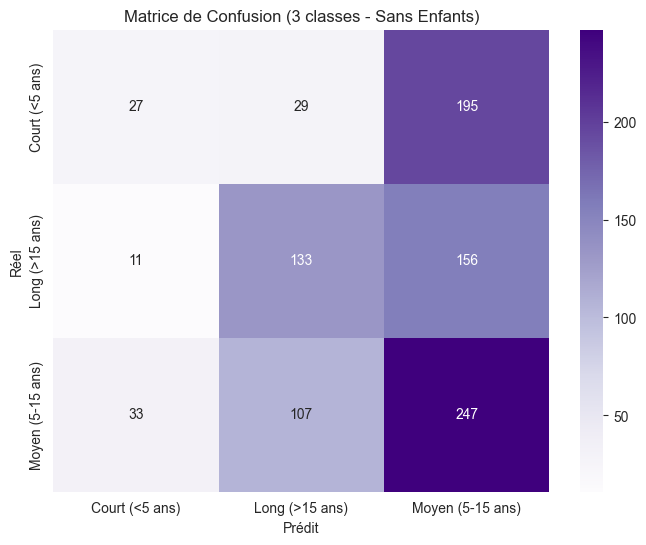

In [8]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Définition des 3 classes
def categorize_duration(years):
    if years < 5:
        return "Court (<5 ans)"
    elif years < 15:
        return "Moyen (5-15 ans)"
    else:
        return "Long (>15 ans)"

# On recrée la cible y avec 3 catégories
y_class_3 = df_model['Marriage_duration'].apply(categorize_duration)

# 2. Préparation des données "Honnêtes"
# On enlève la réponse (Marriage_duration) ET la fuite de données (Num_Children)
X_honest_3 = df_model.drop(columns=['Marriage_duration', 'Num_Children'])

# 3. Split Train/Test
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_honest_3, y_class_3, test_size=0.2, random_state=42)

# 4. Entraînement (On tente le Boosting directement pour maximiser le score)
# Si vous préférez le Random Forest, remplacez GradientBoostingClassifier par RandomForestClassifier
clf_3 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
clf_3.fit(X_train_3, y_train_3)

# 5. Prédiction
y_pred_3 = clf_3.predict(X_test_3)

print("--- RÉSULTATS : 3 CLASSES (SANS ENFANTS) ---")
print(classification_report(y_test_3, y_pred_3))

# 6. Visualisation
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_3, y_pred_3), annot=True, fmt='d', cmap='Purples',
            xticklabels=clf_3.classes_, yticklabels=clf_3.classes_)
plt.title("Matrice de Confusion (3 classes - Sans Enfants)")
plt.ylabel("Réel")
plt.xlabel("Prédit")
plt.show()